# Python Lesson 64: Moments, Skewness, Kurtosis and Quantiles

**Concept page:** `wiki/concepts/moments-skewness-kurtosis-and-quantiles.md` · **Area:** statistics

**You will be able to:**
- compute standardised moments
- distinguish equal-mean-equal-variance distributions
- compute quantiles and fences
- draw a KDE

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Lottery vs insurance

In [2]:
def mom(vals,p,k): vals=np.array(vals,float);p=np.array(p); return (p*vals**k).sum()
lot=([-1,99],[.99,.01]); ins=([1,-99],[.99,.01])
for nm,(v,p) in (('lottery',lot),('insurance',ins)):
    m=mom(v,p,1); var=mom(v,p,2)-m**2; sk=(((np.array(v)-m)/np.sqrt(var))**3*np.array(p)).sum(); print(nm,m,var,mom(v,p,3),round(sk,2))

lottery 0.0 99.0 9702.0 9.85
insurance 0.0 99.0 -9702.0 -9.85


## 2. Kurtosis: same mean, variance, skew

In [3]:
g1=([-1,1],[.5,.5]); g2=([-10,-.1,.1,10],np.array([1,100,100,1])/202)
for v,p in (g1,g2): v=np.array(v);p=np.array(p); print((p*v**2).sum(),(p*v**3).sum(),(p*v**4).sum())    # 1,0,1 and 1,0,99.01

1.0 0.0 1.0
1.0 0.0 99.01


## 3. Quantiles, IQR and box-plot fences

In [4]:
d=np.array([8.7,14.2,18.3,18.4,23.2,25.9,29.7,35.2,51.2,54.7,65.9,75])
print(np.percentile(d,25),np.percentile(d,25,method='midpoint'))      # 18.375 (linear) vs 18.35 (midpoint rule)
q1,q2,q3=np.percentile(d,[25,50,75]); print(q1,q2,q3,q3+1.5*(q3-q1))

18.375 18.35
18.375 27.799999999999997 52.075 102.625


## 4. KDE = sum of small Gaussians

True


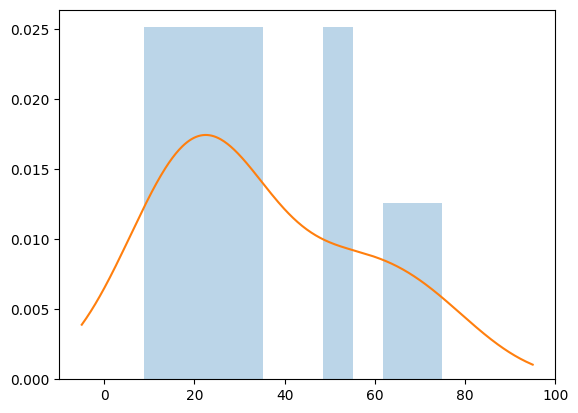

In [5]:
from scipy import stats
xs=np.linspace(-5,95,400); kde=stats.gaussian_kde(d); manual=np.mean([stats.norm.pdf(xs,loc=v,scale=kde.factor*d.std(ddof=1)) for v in d],axis=0)
print(np.allclose(kde(xs),manual,atol=1e-3)); plt.hist(d,density=True,alpha=.3); plt.plot(xs,kde(xs)); plt.show()

## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Grade 8 and 10 give the mean, median, mode of grouped data; quantiles are the generalisation of the median ([[concepts/descriptive-statistics-and-anscombe]]).

In [6]:
print(np.median(d))

27.799999999999997


## Exercises

**Exercise 1.** Compute the skewness of an exponential sample (theory: 2) with scipy.stats.skew.

In [7]:
# your code here

**Exercise 2.** Compute excess kurtosis for a normal sample (theory: 0).

In [8]:
# your code here

## Solutions
*(Try the exercises first!)*

In [9]:
# Solution 1
s=stats.skew(np.random.default_rng(0).exponential(size=200000)); print(s); assert abs(s-2)<0.1

2.010672050146331


In [10]:
# Solution 2
k=stats.kurtosis(np.random.default_rng(0).normal(size=200000)); print(k); assert abs(k)<0.1

0.007905055950537587
